In [47]:
import pyreadr
import anndata as ad 
import pandas as pd
import numpy as np
import scanpy as sc 
import os
import rpy2.robjects as ro
from rpy2.robjects import default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
from sklearn.preprocessing import StandardScaler
from scipy import sparse

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy import sparse

from sklearn.model_selection import train_test_split

In [48]:
# load object
adata = sc.read_h5ad("/home/ubuntu/M_smartsva_corrected_with_SH_annot_filtered.h5ad")

print(adata)
print("obs columns:", adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 984 × 759345
    obs: 'sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source'
obs columns: ['sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source']


In [49]:
def shuffle_labels(adata, label_col="endo", seed=0, out_col="endo_shuf"):
    rng = np.random.default_rng(seed)
    adata_perm = adata.copy()
    y = adata_perm.obs[label_col].to_numpy().copy()
    rng.shuffle(y)
    adata_perm.obs[out_col] = y
    return adata_perm

In [50]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [51]:
print("=== TRAIN SPLIT ===")
print("Shape:", X_train.shape)
print("Sparse:", sparse.issparse(X_train))
print("y counts:", np.unique(y_train, return_counts=True))

print("\n=== TEST SPLIT ===")
print("Shape:", X_test.shape)
print("Sparse:", sparse.issparse(X_test))
print("y counts:", np.unique(y_test, return_counts=True))

=== TRAIN SPLIT ===
Shape: (787, 759345)
Sparse: False
y counts: (array([0, 1]), array([278, 509]))

=== TEST SPLIT ===
Shape: (197, 759345)
Sparse: False
y counts: (array([0, 1]), array([ 69, 128]))


In [52]:
def cv_auc(model, X, y, n_splits=3, random_state=42):  # 3 folds for speed
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean(), scores.std() 

In [53]:
# ============================================
# Helper function: model evaluation
# ============================================

def eval_model(name, model, X_train, y_train, X_test, y_test, plot=True):
    model.fit(X_train, y_train)

    y_score_train = model.predict_proba(X_train)[:, 1]
    y_score_test  = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, y_score_train)
    test_auc  = roc_auc_score(y_test,  y_score_test)

    if hasattr(model, "named_steps"):
        coef = model.named_steps["logreg"].coef_
    else:
        coef = model.coef_

    nnz = int(np.sum(np.abs(coef) > 1e-8))

    print(f"{name}: train_AUC={train_auc:.3f}  test_AUC={test_auc:.3f}  nonzero_coef={nnz}")

    if plot:
        fpr, tpr, _ = roc_curve(y_test, y_score_test)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {name}")
        plt.legend()
        plt.show()

    return {
        "name": name,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "nnz": nnz,
        "model": model
    }

In [54]:
Cs = np.logspace(-6, 2, 25)

In [55]:
def ridge_loop(X_train, y_train, X_test, y_test, Cs, random_state=42):
    all_results = []

    # Detect sparse matrix
    is_sparse = sparse.issparse(X_train)
    with_mean = not is_sparse  # can't center sparse matrices

    for C_val in tqdm(Cs, desc="Ridge (L2) over C"):

        ridge_pipe = Pipeline([
            ("scaler", StandardScaler(with_mean=with_mean)),
            ("logreg", LogisticRegression(
                penalty="l2",
                C=C_val,
                solver="lbfgs" if not is_sparse else "saga",
                max_iter=5000,
                tol=1e-3,
                verbose=0, 
                n_jobs=-1 if is_sparse else None,
                random_state=random_state
            ))
        ])

        # CV
        cv_mean, cv_std = cv_auc(
            ridge_pipe,
            X_train,
            y_train,
            n_splits=5,
            random_state=random_state
        )

        # Fit on full training set + evaluate on test
        r = eval_model(
            f"Ridge (L2, C={C_val})",
            ridge_pipe,
            X_train,
            y_train,
            X_test,
            y_test,
            plot=False 
        )

        logreg = r["model"].named_steps["logreg"]
        print("   -> n_iter_:", logreg.n_iter_, "| max_iter:", logreg.max_iter)

        r["penalty"] = "L2"
        r["C"] = C_val
        r["cv_auc_mean"] = cv_mean
        r["cv_auc_std"]  = cv_std

        print(f"   -> CV_AUC={cv_mean:.3f} ± {cv_std:.3f}")
        print("-" * 60)

        all_results.append(r)

    return all_results

Ridge (L2) over C:   4%|▍         | 1/25 [00:46<18:47, 46.99s/it]

Ridge (L2, C=1e-06): train_AUC=0.997  test_AUC=0.482  nonzero_coef=758813
   -> n_iter_: [15] | max_iter: 5000
   -> CV_AUC=0.528 ± 0.056
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:33<17:47, 46.42s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=0.999  test_AUC=0.477  nonzero_coef=759048
   -> n_iter_: [17] | max_iter: 5000
   -> CV_AUC=0.529 ± 0.056
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:19<17:06, 46.65s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [20:50<00:34, 34.53s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.511  nonzero_coef=759338
   -> n_iter_: [9] | max_iter: 5000
   -> CV_AUC=0.507 ± 0.057
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [21:23<00:00, 51.34s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.511  nonzero_coef=759337
   -> n_iter_: [9] | max_iter: 5000
   -> CV_AUC=0.507 ± 0.057
------------------------------------------------------------

Permutation 1
Best C: 2.1544346900318822e-06
Train AUC: 0.999
Test AUC: 0.477
CV AUC: 0.529


Best Ridge Perm 1 (C=2.1544346900318822e-06): train_AUC=0.999  test_AUC=0.477  nonzero_coef=759048


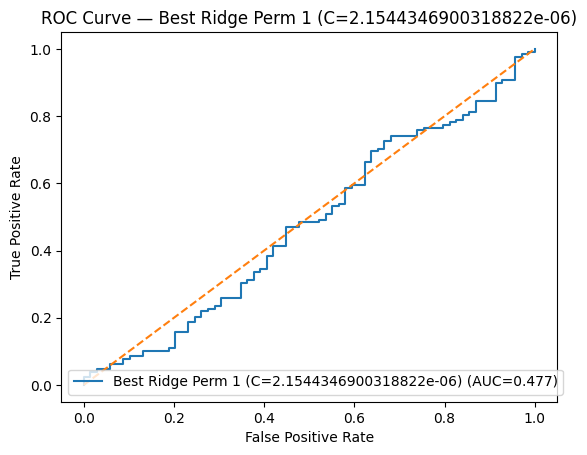

Ridge (L2) over C:   4%|▍         | 1/25 [00:40<16:20, 40.84s/it]

Ridge (L2, C=1e-06): train_AUC=0.998  test_AUC=0.498  nonzero_coef=758750
   -> n_iter_: [15] | max_iter: 5000
   -> CV_AUC=0.495 ± 0.024
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:22<15:44, 41.07s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=0.999  test_AUC=0.494  nonzero_coef=759037
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.494 ± 0.024
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:03<15:04, 41.12s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [23:53<00:46, 46.31s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.474  nonzero_coef=759341
   -> n_iter_: [19] | max_iter: 5000
   -> CV_AUC=0.488 ± 0.016
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [24:38<00:00, 59.14s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.474  nonzero_coef=759345
   -> n_iter_: [19] | max_iter: 5000
   -> CV_AUC=0.488 ± 0.016
------------------------------------------------------------

Permutation 2
Best C: 1e-06
Train AUC: 0.998
Test AUC: 0.498
CV AUC: 0.495


Best Ridge Perm 2 (C=1e-06): train_AUC=0.998  test_AUC=0.498  nonzero_coef=758750


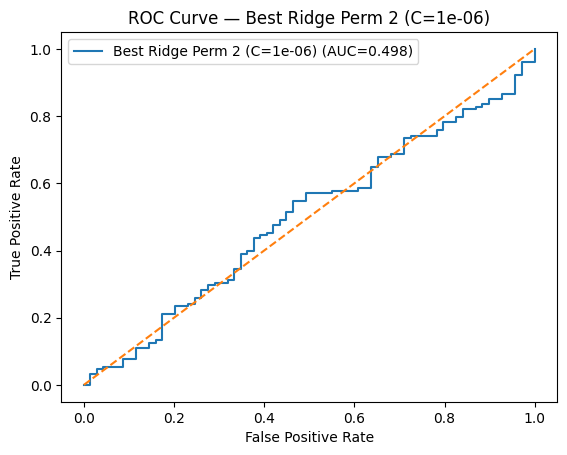

Ridge (L2) over C:   4%|▍         | 1/25 [00:40<16:16, 40.69s/it]

Ridge (L2, C=1e-06): train_AUC=0.995  test_AUC=0.485  nonzero_coef=758764
   -> n_iter_: [14] | max_iter: 5000
   -> CV_AUC=0.410 ± 0.028
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:21<15:42, 40.97s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=0.998  test_AUC=0.476  nonzero_coef=759021
   -> n_iter_: [17] | max_iter: 5000
   -> CV_AUC=0.410 ± 0.030
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:04<15:19, 41.80s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [21:09<00:36, 36.39s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.466  nonzero_coef=759338
   -> n_iter_: [10] | max_iter: 5000
   -> CV_AUC=0.441 ± 0.023
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [21:44<00:00, 52.18s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.466  nonzero_coef=759341
   -> n_iter_: [10] | max_iter: 5000
   -> CV_AUC=0.441 ± 0.023
------------------------------------------------------------

Permutation 3
Best C: 0.004641588833612777
Train AUC: 1.000
Test AUC: 0.474
CV AUC: 0.453


Best Ridge Perm 3 (C=0.004641588833612777): train_AUC=1.000  test_AUC=0.474  nonzero_coef=759321


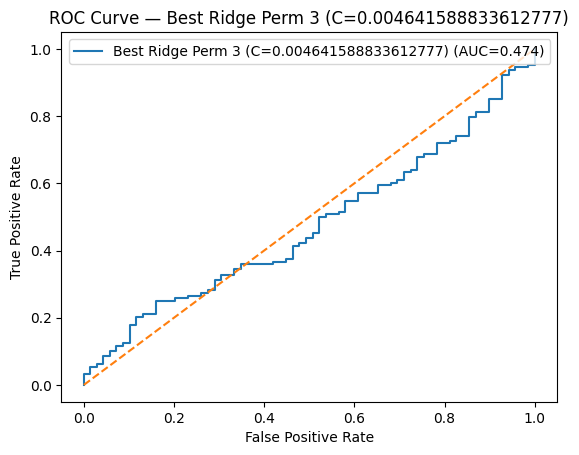

Ridge (L2) over C:   4%|▍         | 1/25 [00:40<16:20, 40.87s/it]

Ridge (L2, C=1e-06): train_AUC=0.999  test_AUC=0.535  nonzero_coef=758823
   -> n_iter_: [15] | max_iter: 5000
   -> CV_AUC=0.570 ± 0.025
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:21<15:37, 40.77s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=1.000  test_AUC=0.542  nonzero_coef=759053
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.575 ± 0.026
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:03<15:05, 41.15s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [17:46<00:30, 30.09s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.508  nonzero_coef=759345
   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.571 ± 0.017
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [18:15<00:00, 43.82s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.508  nonzero_coef=759345
   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.571 ± 0.017
------------------------------------------------------------

Permutation 4
Best C: 0.01
Train AUC: 1.000
Test AUC: 0.509
CV AUC: 0.593


Best Ridge Perm 4 (C=0.01): train_AUC=1.000  test_AUC=0.509  nonzero_coef=759343


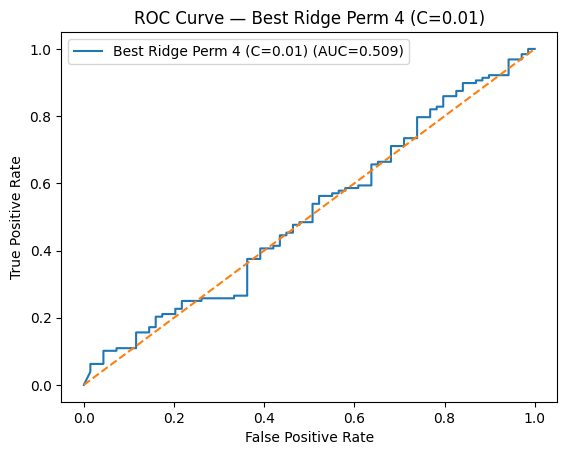

Ridge (L2) over C:   4%|▍         | 1/25 [00:40<16:14, 40.60s/it]

Ridge (L2, C=1e-06): train_AUC=0.999  test_AUC=0.472  nonzero_coef=758818
   -> n_iter_: [15] | max_iter: 5000
   -> CV_AUC=0.477 ± 0.043
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:21<15:37, 40.76s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=1.000  test_AUC=0.469  nonzero_coef=759025
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.478 ± 0.045
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:04<15:14, 41.57s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [20:52<00:34, 34.49s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.484  nonzero_coef=759342
   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.499 ± 0.044
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [21:25<00:00, 51.41s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.484  nonzero_coef=759342
   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.499 ± 0.044
------------------------------------------------------------

Permutation 5
Best C: 0.21544346900318823
Train AUC: 1.000
Test AUC: 0.484
CV AUC: 0.499


Best Ridge Perm 5 (C=0.21544346900318823): train_AUC=1.000  test_AUC=0.484  nonzero_coef=759340


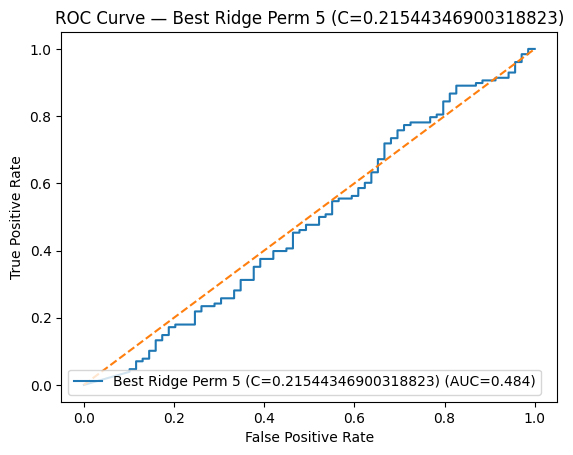

Ridge (L2) over C:   4%|▍         | 1/25 [00:41<16:38, 41.58s/it]

Ridge (L2, C=1e-06): train_AUC=1.000  test_AUC=0.514  nonzero_coef=758772
   -> n_iter_: [15] | max_iter: 5000
   -> CV_AUC=0.492 ± 0.039
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:23<15:55, 41.56s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=1.000  test_AUC=0.512  nonzero_coef=759046
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.495 ± 0.041
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:06<15:30, 42.30s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [20:43<00:34, 34.20s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.549  nonzero_coef=759341
   -> n_iter_: [6] | max_iter: 5000
   -> CV_AUC=0.510 ± 0.031
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [21:15<00:00, 51.03s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.549  nonzero_coef=759342
   -> n_iter_: [6] | max_iter: 5000
   -> CV_AUC=0.510 ± 0.031
------------------------------------------------------------

Permutation 6
Best C: 0.004641588833612777
Train AUC: 1.000
Test AUC: 0.504
CV AUC: 0.523


Best Ridge Perm 6 (C=0.004641588833612777): train_AUC=1.000  test_AUC=0.504  nonzero_coef=759329


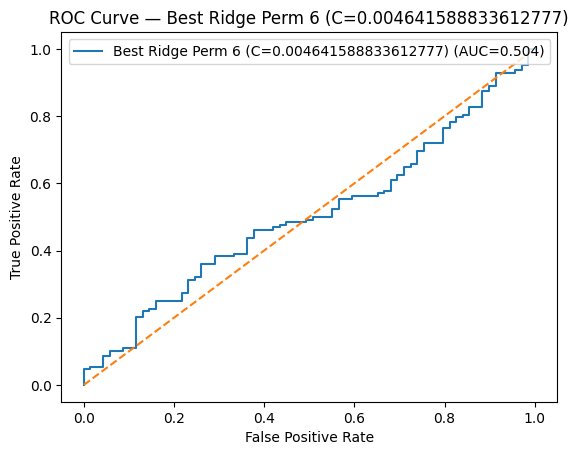

Ridge (L2) over C:   4%|▍         | 1/25 [00:40<16:22, 40.93s/it]

Ridge (L2, C=1e-06): train_AUC=0.998  test_AUC=0.503  nonzero_coef=758780
   -> n_iter_: [15] | max_iter: 5000
   -> CV_AUC=0.520 ± 0.039
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:21<15:32, 40.53s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=0.999  test_AUC=0.500  nonzero_coef=759051
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.516 ± 0.041
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:02<15:03, 41.05s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [20:20<00:33, 33.50s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.510  nonzero_coef=759342
   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.494 ± 0.053
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [20:53<00:00, 50.12s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.510  nonzero_coef=759343
   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.494 ± 0.053
------------------------------------------------------------

Permutation 7
Best C: 1e-06
Train AUC: 0.998
Test AUC: 0.503
CV AUC: 0.520


Best Ridge Perm 7 (C=1e-06): train_AUC=0.998  test_AUC=0.503  nonzero_coef=758780


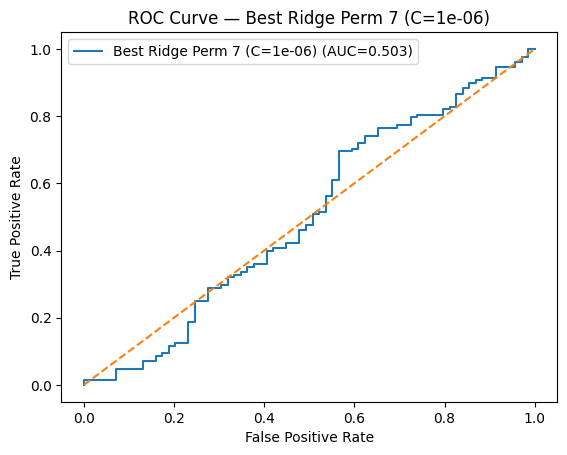

Ridge (L2) over C:   4%|▍         | 1/25 [00:40<16:17, 40.72s/it]

Ridge (L2, C=1e-06): train_AUC=0.997  test_AUC=0.451  nonzero_coef=758800
   -> n_iter_: [14] | max_iter: 5000
   -> CV_AUC=0.506 ± 0.042
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:21<15:43, 41.03s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=0.998  test_AUC=0.448  nonzero_coef=759055
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.503 ± 0.043
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:04<15:15, 41.60s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [21:23<00:36, 36.36s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.454  nonzero_coef=759338
   -> n_iter_: [10] | max_iter: 5000
   -> CV_AUC=0.497 ± 0.057
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [21:58<00:00, 52.74s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.454  nonzero_coef=759340
   -> n_iter_: [10] | max_iter: 5000
   -> CV_AUC=0.497 ± 0.057
------------------------------------------------------------

Permutation 8
Best C: 1e-06
Train AUC: 0.997
Test AUC: 0.451
CV AUC: 0.506


Best Ridge Perm 8 (C=1e-06): train_AUC=0.997  test_AUC=0.451  nonzero_coef=758800


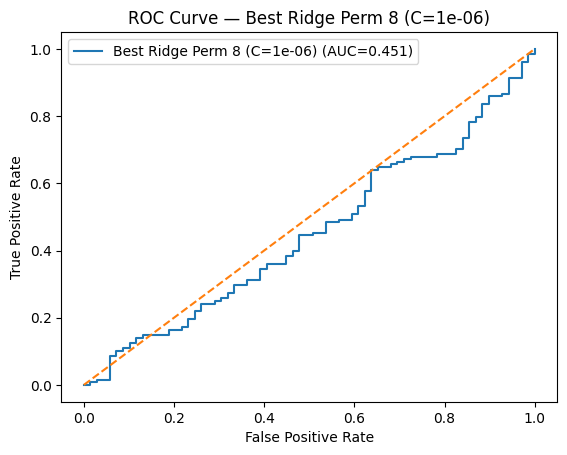

Ridge (L2) over C:   4%|▍         | 1/25 [00:40<16:16, 40.69s/it]

Ridge (L2, C=1e-06): train_AUC=0.999  test_AUC=0.472  nonzero_coef=758783
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.474 ± 0.032
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:21<15:36, 40.71s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=1.000  test_AUC=0.472  nonzero_coef=759026
   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.480 ± 0.034
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:03<15:10, 41.38s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [19:38<00:32, 32.70s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.435  nonzero_coef=759343
   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.496 ± 0.039
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [20:10<00:00, 48.41s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.435  nonzero_coef=759343
   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.496 ± 0.039
------------------------------------------------------------

Permutation 9
Best C: 0.004641588833612777
Train AUC: 1.000
Test AUC: 0.529
CV AUC: 0.521


Best Ridge Perm 9 (C=0.004641588833612777): train_AUC=1.000  test_AUC=0.529  nonzero_coef=759330


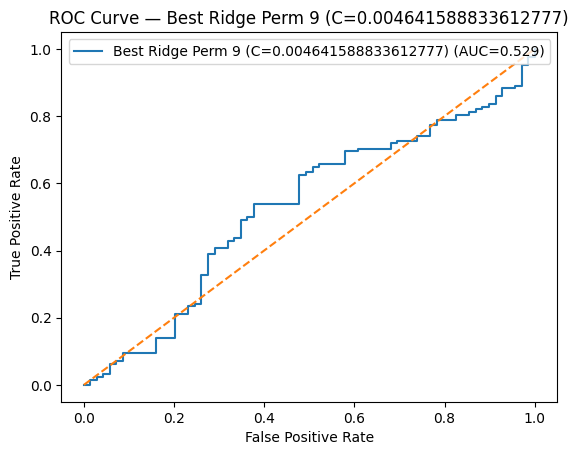

Ridge (L2) over C:   4%|▍         | 1/25 [00:41<16:27, 41.15s/it]

Ridge (L2, C=1e-06): train_AUC=0.998  test_AUC=0.562  nonzero_coef=758760
   -> n_iter_: [15] | max_iter: 5000
   -> CV_AUC=0.477 ± 0.036
------------------------------------------------------------


Ridge (L2) over C:   8%|▊         | 2/25 [01:22<15:47, 41.19s/it]

Ridge (L2, C=2.1544346900318822e-06): train_AUC=0.999  test_AUC=0.558  nonzero_coef=759038
   -> n_iter_: [17] | max_iter: 5000
   -> CV_AUC=0.479 ± 0.037
------------------------------------------------------------


Ridge (L2) over C:  12%|█▏        | 3/25 [02:04<15:12, 41.46s/it]

...

Ridge (L2) over C:  96%|█████████▌| 24/25 [21:11<00:37, 37.56s/it]

Ridge (L2, C=46.41588833612773): train_AUC=1.000  test_AUC=0.526  nonzero_coef=759338
   -> n_iter_: [11] | max_iter: 5000
   -> CV_AUC=0.475 ± 0.015
------------------------------------------------------------


Ridge (L2) over C: 100%|██████████| 25/25 [21:47<00:00, 52.31s/it]

Ridge (L2, C=100.0): train_AUC=1.000  test_AUC=0.526  nonzero_coef=759337
   -> n_iter_: [11] | max_iter: 5000
   -> CV_AUC=0.475 ± 0.015
------------------------------------------------------------

Permutation 10
Best C: 0.00021544346900318823
Train AUC: 1.000
Test AUC: 0.512
CV AUC: 0.498


Best Ridge Perm 10 (C=0.00021544346900318823): train_AUC=1.000  test_AUC=0.512  nonzero_coef=759309


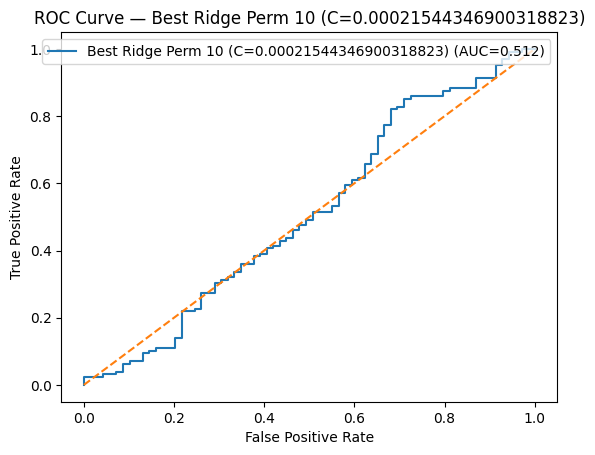

In [56]:
best_perm_runs = []

for i in range(10):
    # Shuffle labels
    adata_perm = shuffle_labels(adata, label_col="endo", seed=i, out_col="endo_shuf")

    X = adata_perm.X
    y = adata_perm.obs["endo_shuf"].astype(int).to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Run ridge without plotting
    results = ridge_loop(
        X_train, y_train,
        X_test, y_test,
        Cs,
        random_state=42
    )

    # Pick best by CV AUC
    best = max(results, key=lambda r: r["cv_auc_mean"])

    print(f"\nPermutation {i+1}")
    print(f"Best C: {best['C']}")
    print(f"Train AUC: {best['train_auc']:.3f}")
    print(f"Test AUC: {best['test_auc']:.3f}")
    print(f"CV AUC: {best['cv_auc_mean']:.3f}")

    # Now re-plot ONLY the best model
    eval_model(
        f"Best Ridge Perm {i+1} (C={best['C']})",
        best["model"],
        X_train, y_train,
        X_test, y_test,
        plot=True
    )

    best_perm_runs.append(best)

    print("=" * 80)